# ISO 20414:2020 — Test 10: Congestion in front of a flight of stairs

150 occupants in an 8 m x 5 m room funnelling into a 2 m corridor that leads to the stair opening (ISO 20414:2020 Table 11). Stairs are modelled as a flat, uniform-width corridor with a free exit at the top, so the only constriction is the room->neck entrance: congestion builds there and relaxes along the neck toward the exit.

In [1]:
from datetime import datetime
print(f"Executed on {datetime.now().astimezone().strftime('%d %B %Y, %H:%M %Z')}")

Executed on 30 May 2026, 20:47 UTC


In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

from jupedsim_scenarios import load_scenario, run_scenario

In [3]:
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "#f7f7f5",
    "axes.edgecolor": "#3a3a3a",
    "axes.labelcolor": "#1d1d1d",
    "axes.titleweight": "bold",
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 11,
    "figure.figsize": (8, 5),
})

## Load and run

In [4]:
SCENARIO_ZIP = Path("scenario_files") / "Iso-10-congestion.zip"
scenario = load_scenario(str(SCENARIO_ZIP))
print(scenario.summary())
result = run_scenario(scenario, seed=42)
df = result.trajectory_dataframe()

Scenario: /work/standards/iso/scenario_files/Iso-10-congestion.zip
  Model:         CollisionFreeSpeedModel
  Seed:          42
  Max time:      400s
  Exits:         1
  Distributions: 1
  Stages:        0
  Zones:         0
  Journeys:      1
  Agents:        ~150
  Journey elems: 2
  Route:         1 distribution, 0 checkpoint, 1 exit
  Sequence:      jps-distributions_0 -> jps-exits_0
    jps-distributions_0: 150 agents


## Density at the room->neck entrance, mid-neck, and near the exit

In [5]:
def rho(sub, x0, x1, y0, y1):
    n = len(sub[(sub.x >= x0) & (sub.x <= x1) & (sub.y >= y0) & (sub.y <= y1)])
    return n / ((x1 - x0) * (y1 - y0))
rows = []
for frame, sub in df.groupby('frame'):
    rows.append({'time_s': frame / result.frame_rate,
                 'rho_room_exit': rho(sub, 3.0, 5.0, 4.5, 5.0),
                 'rho_corridor': rho(sub, 3.0, 5.0, 10.0, 12.0),
                 'rho_stair_base': rho(sub, 3.0, 5.0, 18.0, 20.0)})
density = pd.DataFrame(rows)
density.describe()

,time_s,rho_room_exit,rho_corridor,rho_stair_base
count,700.000000,700.000000,700.000000,700.000000
mean,34.950000,3.224286,1.442143,0.921071
std,20.221688,2.455261,0.833432,0.512995
min,0.000000,0.000000,0.000000,0.000000
25%,17.475000,0.000000,0.937500,0.750000
50%,34.950000,4.000000,1.750000,1.000000
75%,52.425000,5.000000,2.000000,1.250000
max,69.900000,8.000000,2.750000,2.250000


## Plot densities over time

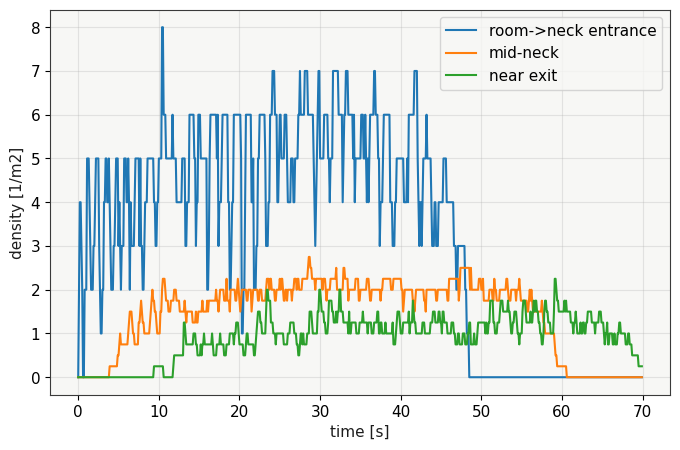

In [6]:
fig, ax = plt.subplots()
ax.plot(density.time_s, density.rho_room_exit, label='room->neck entrance')
ax.plot(density.time_s, density.rho_corridor, label='mid-neck')
ax.plot(density.time_s, density.rho_stair_base, label='near exit')
ax.set_xlabel('time [s]'); ax.set_ylabel('density [1/m2]'); ax.legend()
plt.show()

## Acceptance

The only constriction is the 8 m room funnelling into the 2 m neck, so peak congestion must build at the room->neck entrance and exceed the steady mid-neck density. Density near the free exit is reported, not asserted: it relaxes as agents accelerate out.

In [7]:
peak = density[['rho_room_exit', 'rho_corridor', 'rho_stair_base']].max()
print(peak)
print(f"room->neck entrance peak = {peak['rho_room_exit']:.2f} p/m2, "
      f"mid-neck = {peak['rho_corridor']:.2f} p/m2, near exit = {peak['rho_stair_base']:.2f} p/m2")
assert peak['rho_room_exit'] > peak['rho_corridor'], peak
result.cleanup()

rho_room_exit     8.00
rho_corridor      2.75
rho_stair_base    2.25
dtype: float64
room->neck entrance peak = 8.00 p/m2, mid-neck = 2.75 p/m2, near exit = 2.25 p/m2
